In [20]:
import pandas as pd
import numpy as np

print("Setup successful! Ready to analyse.")

Setup successful! Ready to analyse.


In [21]:
import pandas as pd

# Read the Excel file from the data folder (one level up, then into data/)
df_excel = pd.read_excel('../data/01 Call-Center-Dataset.xlsx')

# Save it as a CSV in the same data folder
df_excel.to_csv('../data/Call_Center_Data.csv', index=False)

print("✅ Conversion complete!")
print(f"Rows: {len(df_excel)}, Columns: {len(df_excel.columns)}")
df_excel.head()

✅ Conversion complete!
Rows: 5000, Columns: 10


,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating
0,ID0001,Diane,2021-01-01,09:12:58,Contract related,Y,Y,109.0,00:02:23,3.0
1,ID0002,Becky,2021-01-01,09:12:58,Technical Support,Y,N,70.0,00:04:02,3.0
2,ID0003,Stewart,2021-01-01,09:47:31,Contract related,Y,Y,10.0,00:02:11,3.0
3,ID0004,Greg,2021-01-01,09:47:31,Contract related,Y,Y,53.0,00:00:37,2.0
4,ID0005,Becky,2021-01-01,10:00:29,Payment related,Y,Y,95.0,00:01:00,3.0


In [22]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd

# Load the CSV we just created
df = pd.read_csv('../data/Call_Center_Data.csv')

# Show first 5 rows
df.head()

,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating
0,ID0001,Diane,2021-01-01,09:12:58,Contract related,Y,Y,109.0,00:02:23,3.0
1,ID0002,Becky,2021-01-01,09:12:58,Technical Support,Y,N,70.0,00:04:02,3.0
2,ID0003,Stewart,2021-01-01,09:47:31,Contract related,Y,Y,10.0,00:02:11,3.0
3,ID0004,Greg,2021-01-01,09:47:31,Contract related,Y,Y,53.0,00:00:37,2.0
4,ID0005,Becky,2021-01-01,10:00:29,Payment related,Y,Y,95.0,00:01:00,3.0


In [24]:
df.shape

(5000, 10)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Call Id                     5000 non-null   str    
 1   Agent                       5000 non-null   str    
 2   Date                        5000 non-null   str    
 3   Time                        5000 non-null   str    
 4   Topic                       5000 non-null   str    
 5   Answered (Y/N)              5000 non-null   str    
 6   Resolved                    5000 non-null   str    
 7   Speed of answer in seconds  4054 non-null   float64
 8   AvgTalkDuration             4054 non-null   str    
 9   Satisfaction rating         4054 non-null   float64
dtypes: float64(2), str(8)
memory usage: 390.8 KB


In [26]:
# Count how many calls were NOT answered
not_answered = (df['Answered (Y/N)'] == 'N').sum()
print(f"Number of unanswered calls: {not_answered}")

Number of unanswered calls: 946


In [27]:
# Convert the Date column from text to a proper datetime
df['Date'] = pd.to_datetime(df['Date'])

# Verify it worked
print("Dtype of Date:", df['Date'].dtype)
print("\nDate range in dataset:")
print("From:", df['Date'].min())
print("To  :", df['Date'].max())

Dtype of Date: datetime64[us]

Date range in dataset:
From: 2021-01-01 00:00:00
To  : 2021-03-31 00:00:00


In [28]:
# The Time column has values like "09:15:30" — let's pull just the hour
df['call_hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

# Quick check
print("First 5 call_hour values:")
print(df['call_hour'].head())
print("\nCall hour range:")
print("Earliest hour:", df['call_hour'].min())
print("Latest hour  :", df['call_hour'].max())

First 5 call_hour values:
0     9
1     9
2     9
3     9
4    10
Name: call_hour, dtype: int32

Call hour range:
Earliest hour: 9
Latest hour  : 18


In [29]:
# Convert HH:MM:SS string to total seconds
df['avg_talk_duration_sec'] = pd.to_timedelta(df['AvgTalkDuration']).dt.total_seconds()

# Compare original vs converted
print("Original vs converted:")
print(df[['AvgTalkDuration', 'avg_talk_duration_sec']].head(10))

print("\nQuick stats on talk duration (in seconds):")
print(df['avg_talk_duration_sec'].describe())

Original vs converted:
  AvgTalkDuration  avg_talk_duration_sec
0        00:02:23                  143.0
1        00:04:02                  242.0
2        00:02:11                  131.0
3        00:00:37                   37.0
4        00:01:00                   60.0
5             NaN                    NaN
6        00:03:40                  220.0
7        00:00:38                   38.0
8        00:06:38                  398.0
9        00:01:04                   64.0

Quick stats on talk duration (in seconds):
count    4054.000000
mean      224.922792
std       111.381555
min        30.000000
25%       130.000000
50%       226.000000
75%       319.000000
max       420.000000
Name: avg_talk_duration_sec, dtype: float64


In [30]:
# Extract day-of-week from the Date column (Monday, Tuesday, etc.)
df['day_of_week'] = df['Date'].dt.day_name()

# Quick check — count calls per weekday
print("Calls per day of the week:")
print(df['day_of_week'].value_counts())

Calls per day of the week:
day_of_week
Monday       770
Saturday     768
Sunday       716
Thursday     712
Friday       680
Wednesday    679
Tuesday      675
Name: count, dtype: int64


In [31]:
# How many UNIQUE dates are in the dataset?
unique_dates = df['Date'].nunique()
print(f"Number of unique dates with calls: {unique_dates}")

# What's the actual average calls per operating day?
total_calls = len(df)
avg_per_operating_day = total_calls / unique_dates
print(f"Total calls: {total_calls}")
print(f"Avg calls per operating day: {avg_per_operating_day:.1f}")

# And by day of the week
print("\nAvg calls per weekday:")
print(df.groupby('day_of_week').size().sort_values(ascending=False))

Number of unique dates with calls: 90
Total calls: 5000
Avg calls per operating day: 55.6

Avg calls per weekday:
day_of_week
Monday       770
Saturday     768
Sunday       716
Thursday     712
Friday       680
Wednesday    679
Tuesday      675
dtype: int64


In [32]:
# Map Y/N to 1/0 — makes them mathematically useful
df['answered_flag'] = df['Answered (Y/N)'].map({'Y': 1, 'N': 0})
df['resolved_flag'] = df['Resolved'].map({'Y': 1, 'N': 0})

# Sanity check
print("Answered flag values:")
print(df['answered_flag'].value_counts())
print("\nResolved flag values:")
print(df['resolved_flag'].value_counts())

Answered flag values:
answered_flag
1    4054
0     946
Name: count, dtype: int64

Resolved flag values:
resolved_flag
1    3646
0    1354
Name: count, dtype: int64


In [33]:
# Build per-agent metrics table
agent_metrics = df.groupby('Agent').agg(
    total_calls=('Call Id', 'count'),
    answered_calls=('answered_flag', 'sum'),
    resolved_calls=('resolved_flag', 'sum'),
    avg_satisfaction=('Satisfaction rating', 'mean'),
    avg_talk_time_sec=('avg_talk_duration_sec', 'mean'),
    avg_speed_of_answer_sec=('Speed of answer in seconds', 'mean')
).reset_index()

# Calculate the rates as percentages
agent_metrics['answer_rate_%']     = (agent_metrics['answered_calls'] / agent_metrics['total_calls']) * 100
agent_metrics['resolution_rate_%'] = (agent_metrics['resolved_calls'] / agent_metrics['answered_calls']) * 100

# Round numbers to 1 decimal so it looks clean
agent_metrics = agent_metrics.round(1)

# Show the table sorted by resolution rate (best agents on top)
agent_metrics.sort_values('resolution_rate_%', ascending=False)

,Agent,total_calls,answered_calls,resolved_calls,avg_satisfaction,avg_talk_time_sec,avg_speed_of_answer_sec,answer_rate_%,resolution_rate_%
3,Greg,624,502,455,3.4,226.8,68.4,80.4,90.6
4,Jim,666,536,485,3.4,228.1,66.3,80.5,90.5
2,Diane,633,501,452,3.4,219.0,66.3,79.1,90.2
1,Dan,633,523,471,3.4,231.2,67.3,82.6,90.1
5,Joe,593,484,436,3.3,224.1,71.0,81.6,90.1
6,Martha,638,514,461,3.5,223.7,69.5,80.6,89.7
0,Becky,631,517,462,3.4,220.0,65.3,81.9,89.4
7,Stewart,582,477,424,3.4,226.2,66.2,82.0,88.9


In [34]:
# Save the main cleaned dataset
df.to_csv('../data/call_center_cleaned.csv', index=False)

# Save the agent performance summary
agent_metrics.to_csv('../data/agent_performance.csv', index=False)

print("✅ Saved successfully!")
print("\nFiles created in your data folder:")
print("  - call_center_cleaned.csv  (main cleaned data, 5000 rows)")
print("  - agent_performance.csv    (agent KPI summary, 8 agents)")

✅ Saved successfully!

Files created in your data folder:
  - call_center_cleaned.csv  (main cleaned data, 5000 rows)
  - agent_performance.csv    (agent KPI summary, 8 agents)


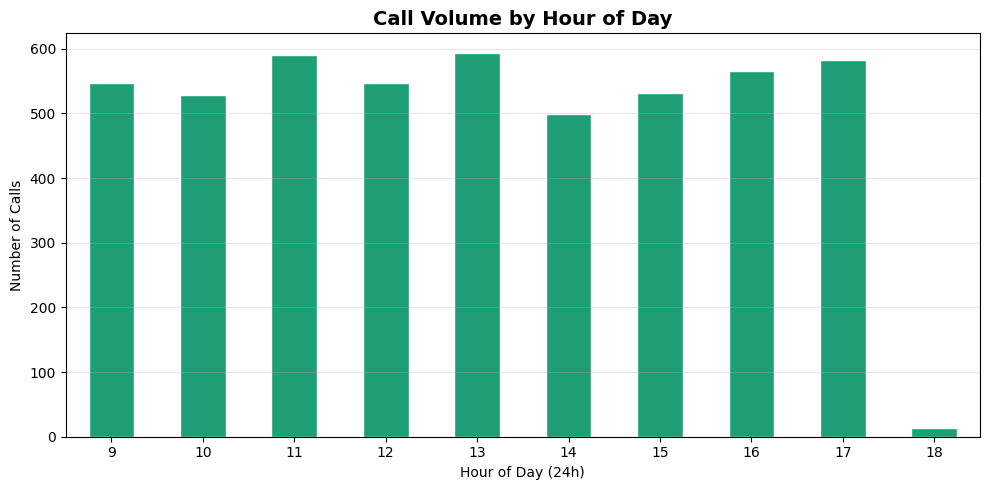

In [35]:
import matplotlib.pyplot as plt

# Count calls per hour
hourly_calls = df['call_hour'].value_counts().sort_index()

# Make the chart
plt.figure(figsize=(10, 5))
hourly_calls.plot(kind='bar', color='#1D9E75', edgecolor='white')
plt.title('Call Volume by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

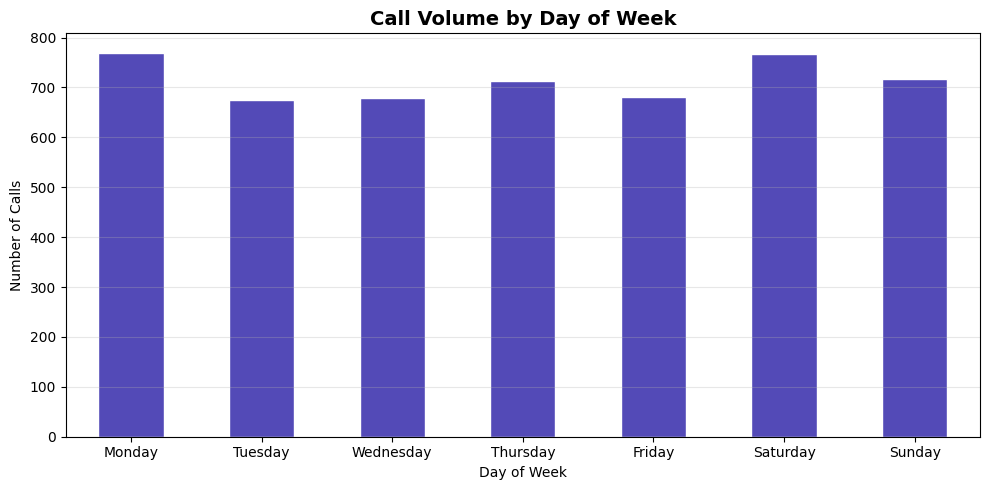

In [36]:
# Order weekdays properly (otherwise pandas sorts alphabetically — annoying!)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_calls = df['day_of_week'].value_counts().reindex(weekday_order)

plt.figure(figsize=(10, 5))
weekday_calls.plot(kind='bar', color='#534AB7', edgecolor='white')
plt.title('Call Volume by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

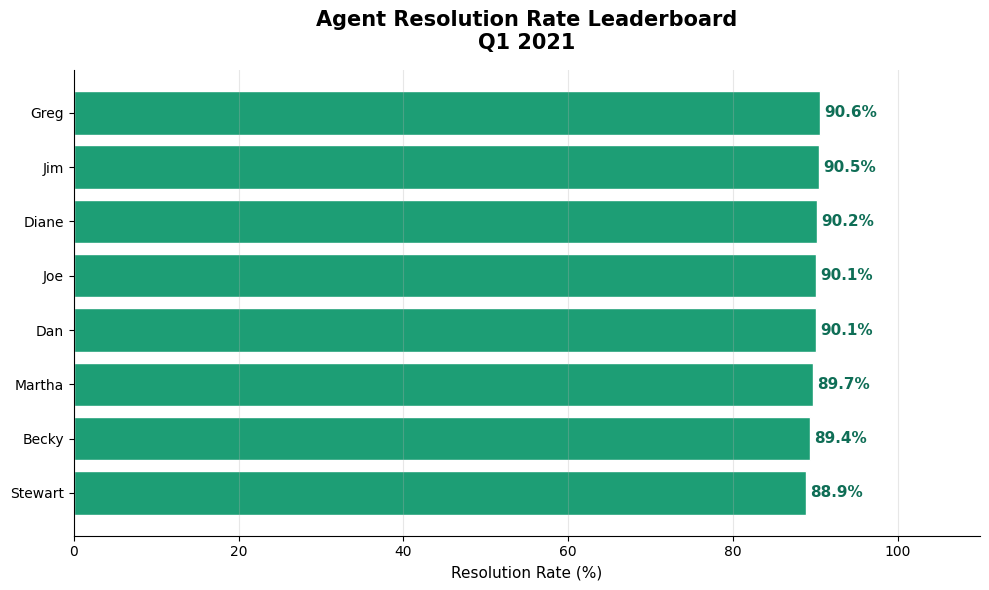

✅ Chart saved to data folder as 'agent_resolution_leaderboard.png'


In [37]:
import matplotlib.pyplot as plt

# Sort agents by resolution rate (lowest at bottom, highest at top — looks better on horizontal bar)
leaderboard = agent_metrics.sort_values('resolution_rate_%', ascending=True)

# Create the chart
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bars
bars = ax.barh(
    leaderboard['Agent'],
    leaderboard['resolution_rate_%'],
    color='#1D9E75',
    edgecolor='white'
)

# Add the percentage labels on each bar
for bar, rate in zip(bars, leaderboard['resolution_rate_%']):
    ax.text(
        bar.get_width() + 0.5,                # x position (just past the end of the bar)
        bar.get_y() + bar.get_height() / 2,    # y position (centred vertically on the bar)
        f'{rate}%',                            # the label text
        va='center',                           # vertical alignment
        fontsize=11,
        fontweight='bold',
        color='#0F6E56'
    )

# Title and labels
ax.set_title('Agent Resolution Rate Leaderboard\nQ1 2021', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Resolution Rate (%)', fontsize=11)
ax.set_ylabel('')

# Make it pretty
ax.set_xlim(0, 110)                            # extra space on the right for labels
ax.spines['top'].set_visible(False)            # remove top border
ax.spines['right'].set_visible(False)          # remove right border
ax.grid(axis='x', alpha=0.3)                   # subtle gridlines

plt.tight_layout()
plt.savefig('../data/agent_resolution_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to data folder as 'agent_resolution_leaderboard.png'")

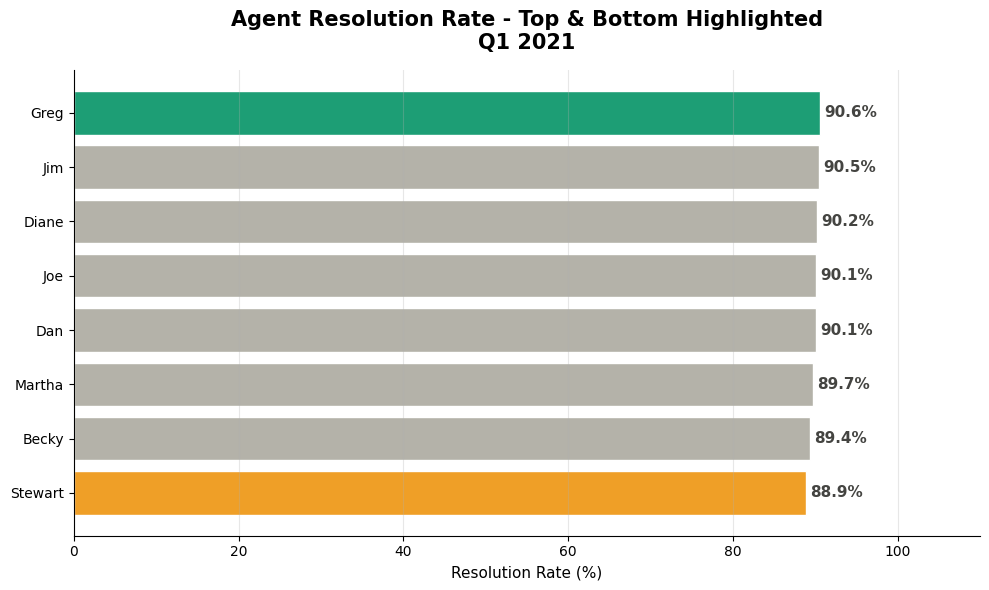

✅ Highlighted version saved!


In [38]:
# Identify top and bottom performers
top_agent    = leaderboard['resolution_rate_%'].idxmax()
bottom_agent = leaderboard['resolution_rate_%'].idxmin()

# Build a colour list — grey by default, special colours for top and bottom
colors = []
for idx in leaderboard.index:
    if idx == top_agent:
        colors.append('#1D9E75')   # teal-green for top
    elif idx == bottom_agent:
        colors.append('#EF9F27')   # amber for needs-attention
    else:
        colors.append('#B4B2A9')   # neutral grey for everyone else

# Make the chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(leaderboard['Agent'], leaderboard['resolution_rate_%'], color=colors, edgecolor='white')

# Label each bar
for bar, rate in zip(bars, leaderboard['resolution_rate_%']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{rate}%', va='center', fontsize=11, fontweight='bold', color='#444441')

# Polish
ax.set_title('Agent Resolution Rate - Top & Bottom Highlighted\nQ1 2021', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Resolution Rate (%)', fontsize=11)
ax.set_xlim(0, 110)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/agent_resolution_leaderboard_highlighted.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Highlighted version saved!")

# 📊 Step 1: Data Cleaning & Exploration - Summary

## 🎯 Project Context
Analysis of a Q1 2021 (Jan-Mar) call centre dataset to support the call centre manager in identifying performance trends and improvement opportunities. Dataset sourced from the PwC Call Centre Trends Dataset (5,000 calls, 8 agents).

## 🛠️ Cleaning & Transformation Steps
1. **Loaded** the original Excel file and converted it to CSV for downstream use in SQL and Power BI.
2. **Diagnosed** missing values: 946 calls (≈19%) had nulls in `Speed of answer`, `AvgTalkDuration`, and `Satisfaction rating`.
3. **Confirmed** these 946 nulls correspond exactly to unanswered calls - kept the nulls intact rather than imputing, since they correctly represent "no measurement" rather than missing data.
4. **Converted data types**:
   - `Date` → datetime (enables time-based grouping)
   - `Time` → extracted `call_hour` integer (for hourly analysis)
   - `AvgTalkDuration` → converted from `HH:MM:SS` text to total seconds
5. **Engineered features**:
   - `day_of_week` - for weekday pattern analysis
   - `answered_flag` and `resolved_flag` - binary 1/0 flags enabling rate calculations via `.mean()`

## 📈 Key Findings
- **Operational scope**: ~55 calls/day across 90 days, operating 9 AM - 7 PM
- **Answer rate**: 81% of calls answered (946 of 5,000 went unanswered - significant service gap)
- **Talk duration**: Mean 3 min 45 sec, capped at exactly 7 min (suggests a system or policy ceiling - worth investigating)
- **Agent consistency**: All 8 agents fall within a tight 1.7-point band on resolution rate (88.9% - 90.6%) - no significant outlier performer. Top performer: Greg. Lowest: Stewart.
- Greg leads with 90.6% resolution; Stewart trails at 88.9% - a 1.7-point spread that suggests team-wide consistency rather than individual performance gaps

## 💡 Business Recommendations
The narrow agent performance spread suggests resolution rate is **not** the main lever for service improvement. Priority focus areas for the next analysis phase:
1. **Investigate the 19% unanswered call rate** - staffing during peak hours? Routing inefficiencies?
2. **Examine speed-of-answer trends** by hour and day-of-week
3. **Topic-level analysis** - are certain topics dragging satisfaction down regardless of agent?

## Limitations
- Dataset limited to Q1 2021 only - seasonal patterns can't be assessed
- No agent tenure or shift data available, so performance can't be controlled for experience
- Topic categorisation is high-level - granular root-cause analysis would need ticket-level data
## 📤 Outputs
- `data/Call_Center_Data.csv` - original Excel converted to CSV
- `data/call_center_cleaned.csv` - fully cleaned dataset with engineered features (ready for SQL & Power BI)
- `data/agent_performance.csv` - per-agent KPI summary table
- `data/agent_resolution_leaderboard_highlighted.png` - performance visual

## 🚀 Next Steps
- **Step 2 (SQL)**: Load `call_center_cleaned.csv` into SQLite and run KPI queries (calls by topic, hourly resolution trends, agent rankings)
- **Step 3 (Power BI)**: Build interactive dashboard with manager-level KPIs and agent drill-down
- **Step 4 (Report)**: Executive briefing document
- **Step 5 (GitHub)**: Publish full project with README